<a href="https://www.kaggle.com/code/odekeelijah/employee-attrition-analysis?scriptVersionId=311105027" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import plotly as pl
import re
from datetime import datetime 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/victorjandoe/employee-attrition-dataset/messy_employee_attrition.csv


In [2]:
df1 = pd.read_csv("/kaggle/input/datasets/victorjandoe/employee-attrition-dataset/messy_employee_attrition.csv")
df1.head()

,EmployeeID,Name,Age,Gender,Department,JobRole,Education,JoiningDate,Attrition,Salary,ExperienceYears,PerformanceRating,WorkLocation,MaritalStatus,ManagerID
0,1.0,Yvonne Cooper,28,Unknown,Saless,Exec,Bachelors,2023-07-24,No,₹79553,4.0,3,Onsite,Unknown,NaN
1,2.0,Keith Willis,Thirty,Female,IT,Manager,PhD,April 2017,Yes,44034,22.0,Average,Bangalore,Married,NaN
2,3.0,James Boyd,50,Male,HR,Manager,Bachelors,2019-12-26,No,$97230,10.0,4,Remote,Married,NaN
3,NaN,Candice Young,Thirty,Unknown,Operations,Manager,PhD,July 2020,No,97628,NaN,Average,Chennai,Single,NaN
4,5.0,grace nelson,51,M,Operations,Manager,Bachelors,August 2025,Resigned,85723,17.0,3,Remote,Married,822.0


In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         3337 non-null   float64
 1   Name               5000 non-null   object 
 2   Age                3300 non-null   object 
 3   Gender             5000 non-null   object 
 4   Department         5000 non-null   object 
 5   JobRole            5000 non-null   object 
 6   Education          3966 non-null   object 
 7   JoiningDate        5000 non-null   object 
 8   Attrition          5000 non-null   object 
 9   Salary             5000 non-null   object 
 10  ExperienceYears    2434 non-null   float64
 11  PerformanceRating  5000 non-null   object 
 12  WorkLocation       5000 non-null   object 
 13  MaritalStatus      5000 non-null   object 
 14  ManagerID          1614 non-null   float64
dtypes: float64(3), object(12)
memory usage: 586.1+ KB


In [4]:
df1.describe()

,EmployeeID,ExperienceYears,ManagerID
count,3337.000000,2434.000000,1614.000000
mean,2505.495954,19.013147,562.304833
std,1444.454155,12.531810,257.703803
min,1.000000,-2.000000,100.000000
25%,1261.000000,8.000000,341.250000
50%,2495.000000,19.000000,575.000000
75%,3776.000000,30.000000,778.000000
max,5000.000000,40.000000,999.000000


In [5]:
# creating copy
df=df1

In [6]:
df.isnull().sum()

EmployeeID           1663
Name                    0
Age                  1700
Gender                  0
Department              0
JobRole                 0
Education            1034
JoiningDate             0
Attrition               0
Salary                  0
ExperienceYears      2566
PerformanceRating       0
WorkLocation            0
MaritalStatus           0
ManagerID            3386
dtype: int64

In [7]:
# Define common “empty” placeholders
empty_values = ["", " ", "nan", "none", "NA", "N/A","NAN", "None", "null"]

# Apply to all columns
df = df.replace(empty_values, np.nan)

#### Replacing text of numbers with actual numeric values

In [8]:
df['Age'] = df['Age'].astype(str).str.strip().str.title()
# Replacing text of numbers with actual numeric values
df['Age'] = df['Age'].replace('Thirty', 30)


#### This handles symbols like $, commas, and 'k' notation in Salary

In [9]:
# Function to clean Salary column and convert it into numeric format
# This handles symbols like $, commas, and 'k' notation (e.g. 50k = 50000)

def clean_salary(s):
    if pd.isnull(s):
        return None
    s = str(s).strip()
    s = s.replace('$','')
    s = s.replace(',','')
    s = re.sub(r'[^0-9kK.]', '', s)
    
    # handle 'k' notation
    if s.lower().endswith('k'):
        s = float(s[:-1]) * 1000
    return float(s)

# Apply function to the column (outside the function)
df['Salary'] = df['Salary'].apply(clean_salary)

#### Data Cleaning — Standardizing Variables

In [10]:

# Standardize Attrition values
df['Attrition'] = df['Attrition'].replace({
    'Y': 'Yes',
    'Yes': 'Yes',
    'Resigned': 'Yes',
    'N': 'No',
    'No': 'No'
})



# Standardize JobRole values
df['JobRole'] = df['JobRole'].replace({
    'Exec': 'Executive',
    'Mgr': 'Manager'
})

# Fix Department typos
df['Department'] = df['Department'].replace({
    'Saless': 'Sales',
    'Finanace': 'Finance'
})

# Standardize Gender values
df['Gender'] = (
    df['Gender']
    .astype(str)
    .str.strip()
    .str.title()
    .replace({
        'M': 'Male',
        'F': 'Female'
    })
)

# Standardize Work Location
df['WorkLocation'] = df['WorkLocation'].replace({
    'WFH': 'Remote'
})

In [11]:
df['PerformanceRating'] = (
    df['PerformanceRating']
    .astype(str)
    .str.strip()
    .str.title()
)

# Convert Performance Rating to numeric scale
rating_map = {
    'Poor': 1,
    'Average': 2,
    'Good': 3,
    'Excellent': 4,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4
}

df['PerformanceRating'] = df['PerformanceRating'].map(rating_map)

#### Data Cleaning — Date

In [12]:

# Keep original
df['JoiningDate_Original'] = df['JoiningDate'].astype(str).str.strip()

# Initialize
df['JoiningDate'] = pd.NaT

# 1. Parse YYYY-MM-DD format (most common clean dates)
still_na = df['JoiningDate'].isna()
df.loc[still_na, 'JoiningDate'] = pd.to_datetime(
    df.loc[still_na, 'JoiningDate_Original'], 
    format='%Y-%m-%d', 
    errors='coerce'
)

# 2. Parse DD/MM/YYYY and DD/MM/YY format (this fixes your / dates)
still_na = df['JoiningDate'].isna()
df.loc[still_na, 'JoiningDate'] = pd.to_datetime(
    df.loc[still_na, 'JoiningDate_Original'], 
    format='%d/%m/%Y', 
    errors='coerce'
)

# Also try two-digit year version (optional but safe)
still_na = df['JoiningDate'].isna()
df.loc[still_na, 'JoiningDate'] = pd.to_datetime(
    df.loc[still_na, 'JoiningDate_Original'], 
    format='%d/%m/%y', 
    errors='coerce'
)

# 3. Parse text month-year formats (April 2017, July 2020, Jan-00, etc.)
mask_month_text = df['JoiningDate_Original'].str.match(r'^[A-Za-z]', na=False)

month_formats = [
    '%B %Y', '%b %Y',     # April 2017, Jul 2020
    '%B-%Y', '%b-%Y',     # April-2017
    '%B-%y', '%b-%y'      # April-17, Jan-00
]

for fmt in month_formats:
    still_na = df['JoiningDate'].isna()
    if still_na.any():
        df.loc[still_na, 'JoiningDate'] = pd.to_datetime(
            df.loc[still_na, 'JoiningDate_Original'], 
            format=fmt, 
            errors='coerce'
        )

# 4. Force day = 1 ONLY for text-based month-year entries
df.loc[mask_month_text & df['JoiningDate'].notna(), 'JoiningDate'] = \
    df.loc[mask_month_text & df['JoiningDate'].notna(), 'JoiningDate'].apply(
        lambda x: x.replace(day=1) if pd.notnull(x) else x
    )

# 5. Final output as YYYY-MM-DD
df['JoiningDate'] = df['JoiningDate'].dt.strftime('%Y-%m-%d')

# Check results
print(f"Still NaN count: {df['JoiningDate'].isna().sum()}")

Still NaN count: 0


In [13]:
#dropping unwanted column 
df = df.drop(columns=['JoiningDate_Original'])

In [14]:
df.head()

,EmployeeID,Name,Age,Gender,Department,JobRole,Education,JoiningDate,Attrition,Salary,ExperienceYears,PerformanceRating,WorkLocation,MaritalStatus,ManagerID
0,1.0,Yvonne Cooper,28,Unknown,Sales,Executive,Bachelors,2023-07-24,No,79553.0,4.0,3,Onsite,Unknown,NaN
1,2.0,Keith Willis,30,Female,IT,Manager,PhD,2017-04-01,Yes,44034.0,22.0,2,Bangalore,Married,NaN
2,3.0,James Boyd,50,Male,HR,Manager,Bachelors,2019-12-26,No,97230.0,10.0,4,Remote,Married,NaN
3,NaN,Candice Young,30,Unknown,Operations,Manager,PhD,2020-07-01,No,97628.0,NaN,2,Chennai,Single,NaN
4,5.0,grace nelson,51,Male,Operations,Manager,Bachelors,2025-08-01,Yes,85723.0,17.0,3,Remote,Married,822.0


#### Data type corrections

In [15]:
# Converting key columns to numeric format
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['ExperienceYears'] = pd.to_numeric(df['ExperienceYears'], errors='coerce')
df['PerformanceRating'] = pd.to_numeric(df['PerformanceRating'], errors='coerce')

df['JoiningDate'] = pd.to_datetime(df['JoiningDate'], errors='coerce')

cat_cols = [
    'Gender',
    'Department',
    'JobRole',
    'Education',
    'WorkLocation',
    'MaritalStatus',
    'Attrition'
]
df[cat_cols] = df[cat_cols].apply(lambda x: x.astype(str).str.strip().str.title())

In [16]:
df.dtypes

EmployeeID                  float64
Name                         object
Age                         float64
Gender                       object
Department                   object
JobRole                      object
Education                    object
JoiningDate          datetime64[ns]
Attrition                    object
Salary                      float64
ExperienceYears             float64
PerformanceRating             int64
WorkLocation                 object
MaritalStatus                object
ManagerID                   float64
dtype: object

#### Handling Missing Values

##### Handling Missing EmplyeeID

In [17]:
# we shall Create New id by modifying the column starting from 1
df['EmployeeID'] = df.index + 1

# now we make sure ids start from 1
cols = ['EmployeeID'] + [col for col in df.columns if col != 'EmployeeID']
df = df[cols]

##### Handling Missing Age

In [18]:
# Replacing different string formats of missing values with actual NaN
df['Age'] = df['Age'].replace(['Nan', 'nan', 'NAN', 'NaN'], np.nan)

# Counting missing values in Age
missing_count = df['Age'].isnull().sum()
total_count = len(df)

print(f"Missing age: {missing_count} out of {total_count} ({missing_count/total_count*100:.2f}%)")

Missing age: 1700 out of 5000 (34.00%)


In [19]:
# fill in the missing age with average age by department and jobrole 
df['Age'] = df.groupby(['Department','JobRole'])['Age']\
              .transform(lambda x: x.fillna(x.median()))

##### Handling Missing Experience Years

In [20]:
# Replacing different string formats of missing values with actual NaN
df['ExperienceYears'] = df['ExperienceYears'].replace(['Nan', 'nan', 'NAN', 'NaN'], np.nan)

# Counting missing values in ExperienceYears
missing_count = df['ExperienceYears'].isnull().sum()
total_count = len(df)
print(f"Missing age: {missing_count} out of {total_count} ({missing_count/total_count*100:.2f}%)")

Missing age: 2566 out of 5000 (51.32%)


In [21]:
# i assumed that most individuals start working at around age 22
df['ExperienceYears'] = df['ExperienceYears'].fillna(
    df['Age'] - 22
)

# Filling missing values in ManagerID with 'Unknown'
df['ManagerID'] = df['ManagerID'].fillna('Unknown')

In [22]:
df.isnull().sum()

EmployeeID           0
Name                 0
Age                  0
Gender               0
Department           0
JobRole              0
Education            0
JoiningDate          0
Attrition            0
Salary               0
ExperienceYears      0
PerformanceRating    0
WorkLocation         0
MaritalStatus        0
ManagerID            0
dtype: int64

## ORIGINAL vs CLEANED COMPARISON

In [23]:

print("--- ORIGINAL vs CLEANED COMPARISON ---\n")

# Shape
print(f"Shape - Original: {df1.shape} | Cleaned: {df.shape}")

# Missing values
print("\nMissing Values:")
print(pd.DataFrame({
    'Original': df1.isnull().sum(),
    'Cleaned' : df.isnull().sum()
}))

# Numeric Summary Comparison
print("\nNumeric Summary:")
numeric_cols = df.select_dtypes(include='number').columns
summary = pd.concat([
    df1[numeric_cols].describe().round(3),
    df[numeric_cols].describe().round(3)
], axis=1, keys=['Original', 'Cleaned'])

print(summary)

# Data Types
print("\nData Types:")
print(pd.DataFrame({
    'Original': df1.dtypes,
    'Cleaned' : df.dtypes
}))

--- ORIGINAL vs CLEANED COMPARISON ---

Shape - Original: (5000, 15) | Cleaned: (5000, 15)

Missing Values:
                   Original  Cleaned
EmployeeID             1663        0
Name                      0        0
Age                    1700        0
Gender                    0        0
Department                0        0
JobRole                   0        0
Education              1034        0
JoiningDate               0        0
Attrition                 0        0
Salary                    0        0
ExperienceYears        2566        0
PerformanceRating         0        0
WorkLocation              0        0
MaritalStatus             0        0
ManagerID              3386        0

Numeric Summary:
        Original                    Cleaned                        \
      EmployeeID ExperienceYears EmployeeID       Age      Salary   
count   3337.000        2434.000    5000.00  5000.000    5000.000   
mean    2505.496          19.013    2500.50    33.680   69392.535   
std   

### **DATA VISUALIZATION**

#### **Correlation Matrix**

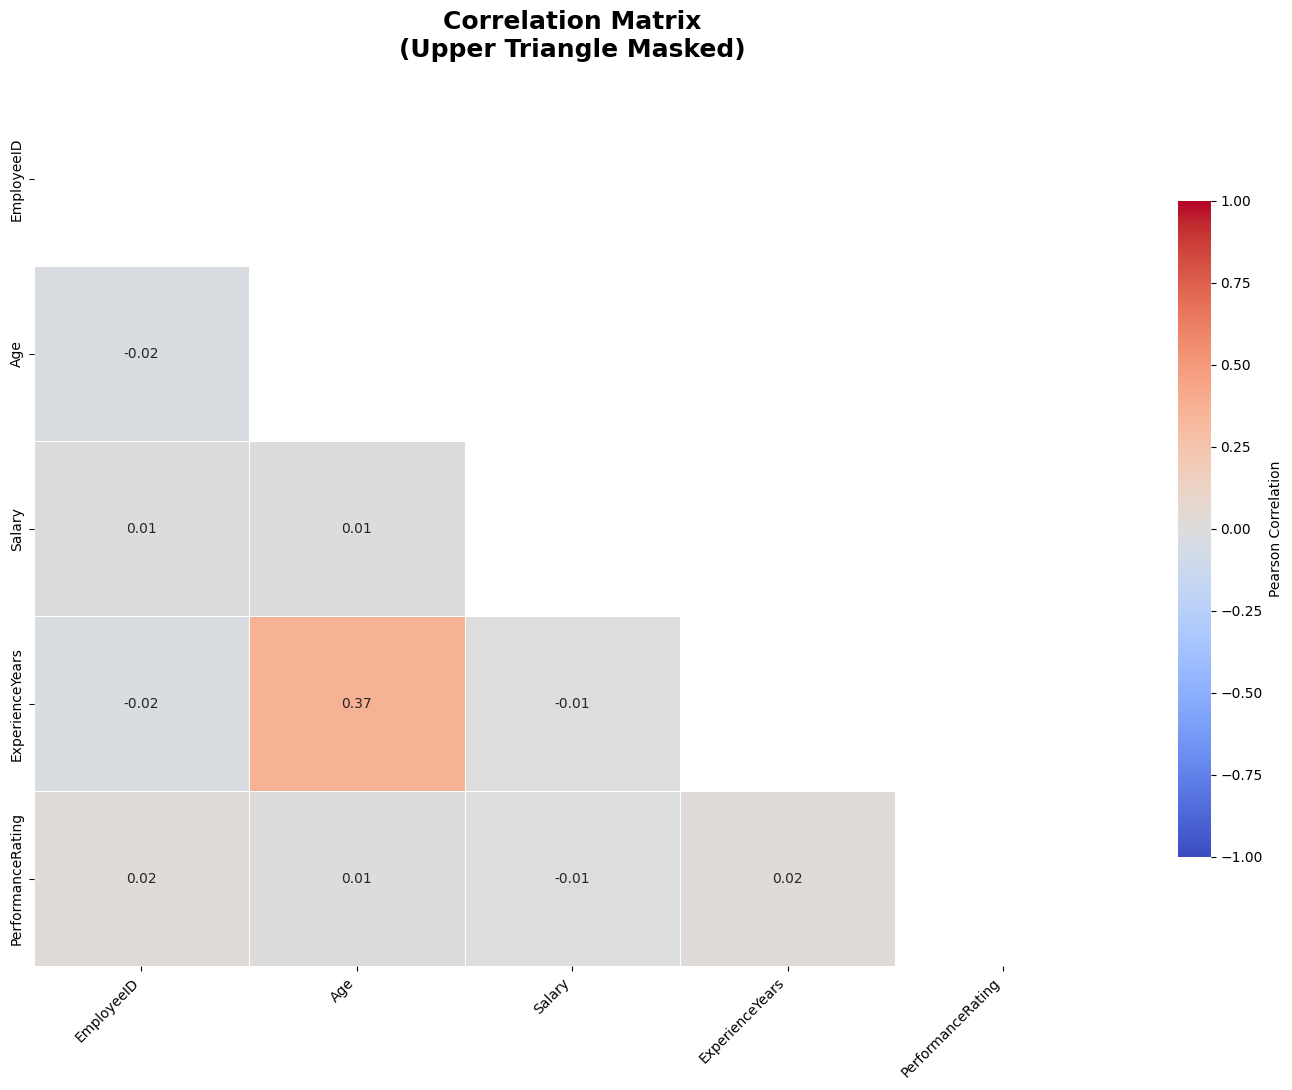

In [24]:

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Compute correlation
corr = numeric_df.corr()

# mask for upper triangle 
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,      
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson Correlation'}
)

plt.title("Correlation Matrix\n(Upper Triangle Masked)", 
          fontsize=18, 
          fontweight='bold', 
          pad=25)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### **Pie chart:** Attrition Distribution

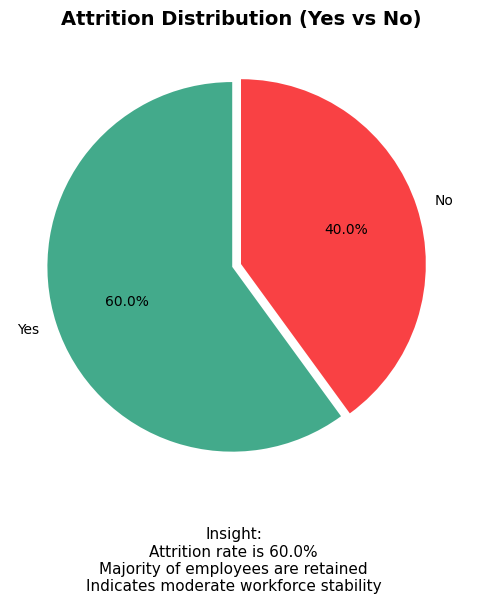

In [25]:

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#43AA8B', '#F94144'],
    explode=(0.05, 0)
)

plt.title("Attrition Distribution (Yes vs No)", fontsize=14, fontweight='bold')

# output text
yes_pct = (attrition_counts['Yes'] / attrition_counts.sum()) * 100

text = (
    "Insight:\n"
    f"Attrition rate is {yes_pct:.1f}%\n"
    "Majority of employees are retained\n"
    "Indicates moderate workforce stability"
)

plt.figtext(
    0.5,
    -0.05,
    text,
    ha='center',
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none')
)

plt.show()

#### 

#### **Box plot:** Salary Distribution by Department and Attrition

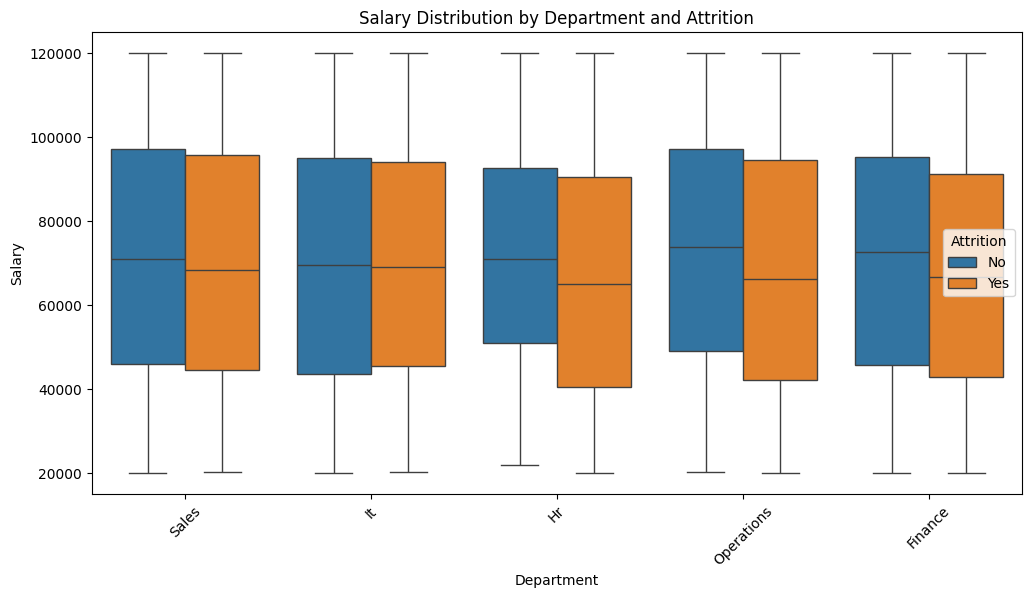


SALARY GAP BY DEPARTMENT :
Department
Hr            5476.57
Operations    4136.36
Finance       2483.49
Sales         1704.08
It            -545.96
Name: Salary_Gap, dtype: float64

Largest Salary Gap Department: Hr : 5476.57
Smallest Salary Gap Department: It : -545.96


In [26]:

#visula
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Department', y='Salary', hue='Attrition')
plt.title("Salary Distribution by Department and Attrition")
plt.xticks(rotation=45)
plt.show()

#salary - Gap
dept_salary = df.groupby(['Department','Attrition'])['Salary'].mean().unstack()

# Calculate gap in money
dept_salary['Salary_Gap'] = dept_salary['No'] - dept_salary['Yes']
dept_salary_sorted = dept_salary.sort_values('Salary_Gap', ascending=False)

# Identify extreme gaps
largest_gap_dept = dept_salary['Salary_Gap'].idxmax()
smallest_gap_dept = dept_salary['Salary_Gap'].idxmin()


# Text outputs
print("\nSALARY GAP BY DEPARTMENT :")
print(dept_salary_sorted['Salary_Gap'].round(2))
print("\nLargest Salary Gap Department:", largest_gap_dept,
      ":", round(dept_salary.loc[largest_gap_dept, 'Salary_Gap'], 2))

print("Smallest Salary Gap Department:", smallest_gap_dept,
      ":", round(dept_salary.loc[smallest_gap_dept, 'Salary_Gap'], 2))

#### **Scatter plot:** Experience Years vs Performance Rating

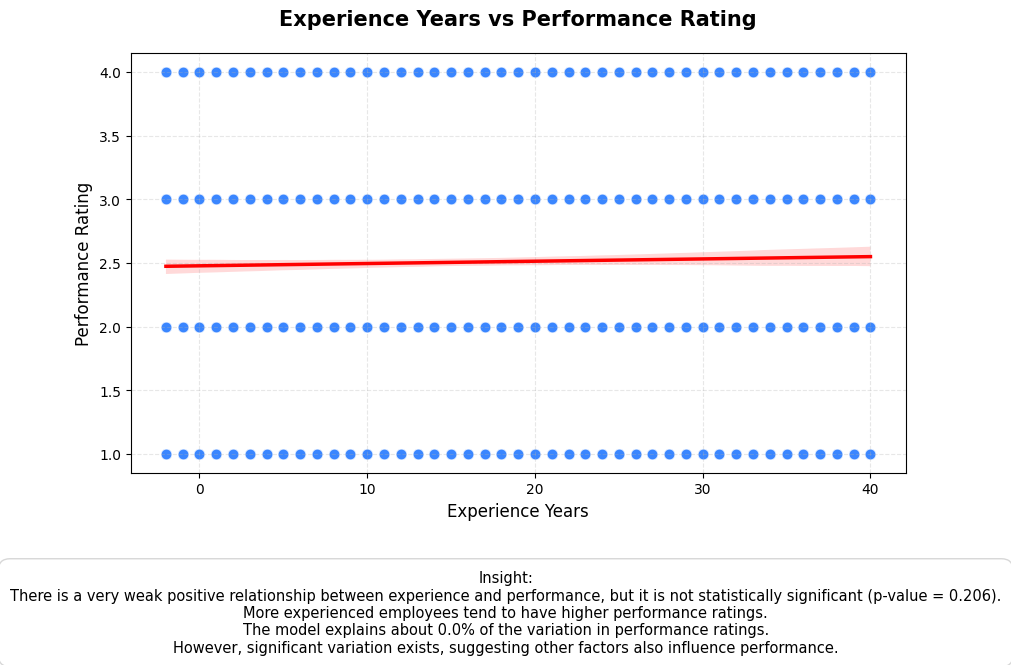

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, linregress


def generate_experience_insight(df, x_col='ExperienceYears', y_col='PerformanceRating'):
    
    # Drop missing values (IMPORTANT FIX)
    df_clean = df[[x_col, y_col]].dropna()

    # Calculate statistics
    corr, p_value = pearsonr(df_clean[x_col], df_clean[y_col])
    slope, intercept, r_value, p_val_reg, std_err = linregress(df_clean[x_col], df_clean[y_col])
    r_squared = r_value**2

    # Determine relationship strength
    if abs(corr) < 0.1:
        strength = "very weak"
    elif abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.5:
        strength = "moderate"
    else:
        strength = "strong"

    direction = "positive" if corr > 0 else "negative"

    # Build insight text
    text = "Insight:\n"

    if p_value < 0.05:
        text += f"There is a {strength} {direction} relationship between experience and performance "
        text += f"(correlation = {corr:.3f}, p-value = {p_value:.3f}).\n"
    else:
        text += f"There is a {strength} {direction} relationship between experience and performance, "
        text += f"but it is not statistically significant (p-value = {p_value:.3f}).\n"

    text += f"More experienced employees tend to have {'higher' if slope > 0 else 'lower'} performance ratings.\n"
    text += f"The model explains about {r_squared*100:.1f}% of the variation in performance ratings.\n"
    text += "However, significant variation exists, suggesting other factors also influence performance."

    return text


# =========================
# PLOT SECTION
# =========================

plt.figure(figsize=(10, 7))

# Scatter plot
sns.scatterplot(
    data=df,
    x='ExperienceYears',
    y='PerformanceRating',
    color='#3A86FF',
    alpha=0.7,
    s=60
)

# Regression line
sns.regplot(
    data=df,
    x='ExperienceYears',
    y='PerformanceRating',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2.5}
)

# Titles and labels
plt.title("Experience Years vs Performance Rating", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Experience Years", fontsize=12)
plt.ylabel("Performance Rating", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

# Generate dynamic insight text
insight_text = generate_experience_insight(df)

# Add text at bottom
plt.subplots_adjust(bottom=0.28)

plt.figtext(
    0.5,
    0.02,
    insight_text,
    ha='center',
    fontsize=10.5,
    va='bottom',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray', boxstyle='round,pad=0.8')
)

plt.show()